# Engenharia de Features
## Parte 3: Feature Engineering — Entregável 7

Opera sobre as features brutas do Entregável 6 e produz um conjunto enriquecido e validado.

| Passo | Operação | Efeito |
|-------|----------|--------|
| 1 | Razões espectrais (theta/alpha, relax, fadiga EMG, assimetria α) | +~90 features |
| 2 | Derivadas temporais Δ e Δ² dentro de cada segmento | ×3 features |
| 3 | Normalização por baseline individual por paciente (label=0) | transforma features |
| 4 | Filtro Spearman (\|r\|<0.05 E p>0.05) + deduplicação (\|r\|>0.95) | −N features |

### Entrada / Saída
- **Entrada**: `data/silver/features_raw.parquet` (24 564 × 1 251)
- **Saída**: `data/silver/features_engineered.parquet`

## 0. Imports e constantes

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as sts
from pathlib import Path
import warnings, time
warnings.filterwarnings('ignore')

ROOT          = Path('..')
FEATURES_PATH = ROOT / 'data' / 'silver' / 'features_raw.parquet'
META_PATH     = ROOT / 'data' / 'silver' / 'windows_metadata.parquet'
OUT_PATH      = ROOT / 'data' / 'silver' / 'features_engineered.parquet'

META_COLS = ['patient_id', 'task_label', 'janela_inicio_s']

print(f'features_raw exists : {FEATURES_PATH.exists()}')
print(f'metadata exists     : {META_PATH.exists()}')

features_raw exists : True
metadata exists     : True


## 1. Carregar dados

In [11]:
print('Carregando dados...')
df      = pd.read_parquet(FEATURES_PATH)
df_meta = pd.read_parquet(META_PATH)

assert len(df) == len(df_meta), f'Desalinhamento: {len(df)} vs {len(df_meta)}'

feat_cols = [c for c in df.columns if c not in META_COLS]
N_WIN     = len(df)
N_FEAT    = len(feat_cols)

print(f'features_raw : {df.shape}')
print(f'Features     : {N_FEAT}')
print(f'Janelas      : {N_WIN:,}')
print(f'Pacientes    : {df["patient_id"].nunique()}')
print(f'Tasks        : {sorted(df_meta["task_id"].unique())}')
print(f'Label        : 0={int((df["task_label"]==0).sum())}  1={int((df["task_label"]==1).sum())}')

Carregando dados...
features_raw : (24564, 1254)
Features     : 1251
Janelas      : 24,564
Pacientes    : 12
Tasks        : ['task_1', 'task_2', 'task_3', 'task_4', 'task_5', 'task_6']
Label        : 0=14386  1=10178


## 2. Passo 1 — Razões entre bandas

| Feature | Fórmula | Interpretação fisiológica |
|---------|---------|--------------------------|
| **Theta/Alpha** | θ / α | Sonolência, carga cognitiva |
| **Relax index** | (α + θ) / β | Relaxamento vs. alerta |
| **Delta/Alpha** | δ / α | Sedação vs. ativação cortical |
| **Alpha asymmetry** | log(R_α / L_α) | Assimetria hemisférica (alterada em Parkinson) |
| **EMG fatigue** | band_low / band_high | Fadiga muscular desloca energia para baixas freq. |

In [12]:
print('Passo 1 — Razões espectrais...')
t0 = time.time()
feat_ratio = {}

# ── EEG: razões clássicas por canal ───────────────────────────────────────────
eeg_chans   = sorted({c.split('__')[0] for c in feat_cols if c.startswith('EEG-')})
n_ratio_eeg = 0
for ch in eeg_chans:
    theta  = df.get(f'{ch}__freq__band_theta')
    alpha  = df.get(f'{ch}__freq__band_alpha')
    beta   = df.get(f'{ch}__freq__band_beta')
    delta_ = df.get(f'{ch}__freq__band_delta')
    if theta is None or alpha is None:
        continue
    a, t = alpha.values, theta.values
    feat_ratio[f'{ch}__ratio__theta_alpha'] = t / (a + 1e-12)
    n_ratio_eeg += 1
    if beta is not None:
        feat_ratio[f'{ch}__ratio__relax_idx']   = (a + t) / (beta.values + 1e-12)
        n_ratio_eeg += 1
    if delta_ is not None:
        feat_ratio[f'{ch}__ratio__delta_alpha'] = delta_.values / (a + 1e-12)
        n_ratio_eeg += 1

# ── Assimetria alpha hemisférica: log(direito / esquerdo) ────────────────────
ASYM_PAIRS = [
    ('EEG-FP1','EEG-FP2'), ('EEG-F3','EEG-F4'),  ('EEG-C3','EEG-C4'),
    ('EEG-P3', 'EEG-P4'),  ('EEG-O1','EEG-O2'),   ('EEG-F7','EEG-F8'),
    ('EEG-P7', 'EEG-P8'),  ('EEG-FC5','EEG-FC6'), ('EEG-CP5','EEG-CP6'),
    ('EEG-FC1','EEG-FC2'), ('EEG-CP1','EEG-CP2'),
]
n_asym = 0
for left, right in ASYM_PAIRS:
    lc, rc = f'{left}__freq__band_alpha', f'{right}__freq__band_alpha'
    if lc in df.columns and rc in df.columns:
        lid, rid = left.split('-')[1], right.split('-')[1]
        feat_ratio[f'EEG__asym__alpha_{lid}_{rid}'] = (
            np.log((df[rc].values + 1e-12) / (df[lc].values + 1e-12))
        )
        n_asym += 1

# ── EMG: índice de fadiga muscular (low / high) ───────────────────────────────
n_fatigue = 0
for emg in ['EMG-RTA', 'EMG-LTA', 'EMG-RGS']:
    lc, hc = f'{emg}__freq__band_low', f'{emg}__freq__band_high'
    if lc in df.columns and hc in df.columns:
        feat_ratio[f'{emg}__ratio__fatigue'] = df[lc].values / (df[hc].values + 1e-12)
        n_fatigue += 1

df       = pd.concat([df, pd.DataFrame(feat_ratio, index=df.index)], axis=1)
ratio_cols = list(feat_ratio.keys())
n_ratio  = len(ratio_cols)

print(f'  EEG theta/alpha, relax, delta/alpha : {n_ratio_eeg}')
print(f'  Assimetria hemisférica alpha        : {n_asym}')
print(f'  Índice de fadiga EMG                : {n_fatigue}')
print(f'  Total razões novas                  : {n_ratio}  ({time.time()-t0:.1f}s)')

Passo 1 — Razões espectrais...
  EEG theta/alpha, relax, delta/alpha : 75
  Assimetria hemisférica alpha        : 11
  Índice de fadiga EMG                : 3
  Total razões novas                  : 89  (0.1s)


## 3. Passo 2 — Derivadas temporais (Δ e Δ²)

```
Δ f(t)  = f(t) − f(t−1)       → velocidade de mudança (1ª derivada discreta)
Δ² f(t) = Δf(t) − Δf(t−1)    → aceleração de mudança (2ª derivada discreta)
```

As diferenças são calculadas **dentro** de cada grupo `(patient_id, session, task_id)`.
A primeira janela de cada segmento recebe Δ = NaN; a segunda recebe Δ² = NaN (propagação via NaN aritmético).

> Motivação: em FoG, a *transição* entre estados pode ser mais discriminativa do que o valor absoluto da feature.

In [13]:
print('Passo 2 — Derivadas temporais (Δ e Δ²)...')
t0 = time.time()

# Ordenar por (paciente, sessão, task, n_inicio) para diffs corretos
sort_df = pd.DataFrame({
    'patient_id': df_meta['patient_id'].values,
    'session'   : df_meta['session'].values,
    'task_id'   : df_meta['task_id'].values,
    'n_inicio'  : df_meta['n_inicio'].values,
    'orig_idx'  : np.arange(N_WIN),
}).sort_values(['patient_id','session','task_id','n_inicio']).reset_index(drop=True)

perm     = sort_df['orig_idx'].values     # sorted_pos → orig_pos
inv_perm = np.argsort(perm)               # orig_pos  → sorted_pos

# Máscara de fronteira entre grupos
grp      = sort_df[['patient_id','session','task_id']].values
is_bnd   = (grp != np.vstack([grp[0:1], grp[:-1]])).any(axis=1)
is_bnd[0] = True

# Feature matrix na ordem ordenada
base_cols = feat_cols + ratio_cols
X = df[base_cols].values[perm].astype(np.float32)   # (N_WIN, N_BASE)

# Δ
dX      = np.empty_like(X)
dX[0]   = np.nan
dX[1:]  = X[1:] - X[:-1]
dX[is_bnd] = np.nan

# Δ² (NaN propaga automaticamente onde dX era NaN)
d2X     = np.empty_like(dX)
d2X[0]  = np.nan
d2X[1:] = dX[1:] - dX[:-1]
d2X[is_bnd] = np.nan

# Restaurar ordem original
dX  = dX[inv_perm]
d2X = d2X[inv_perm]

delta_cols  = [f'{c}__delta'  for c in base_cols]
delta2_cols = [f'{c}__delta2' for c in base_cols]

df = pd.concat([
    df,
    pd.DataFrame(dX,  columns=delta_cols,  index=df.index),
    pd.DataFrame(d2X, columns=delta2_cols, index=df.index),
], axis=1)
del X, dX, d2X

n_base  = len(base_cols)
n_total = N_FEAT + n_ratio + 2 * n_base
n_bnd   = int(is_bnd.sum())
print(f'  Base (raw + razões) : {n_base}')
print(f'  Δ features          : {n_base}')
print(f'  Δ² features         : {n_base}')
print(f'  Total acumulado     : {n_total}')
print(f'  Fronteiras (Δ=NaN) : {n_bnd} janelas ({n_bnd/N_WIN*100:.1f}%)  ({time.time()-t0:.1f}s)')

Passo 2 — Derivadas temporais (Δ e Δ²)...
  Base (raw + razões) : 1340
  Δ features          : 1340
  Δ² features         : 1340
  Total acumulado     : 4020
  Fronteiras (Δ=NaN) : 56 janelas (0.2%)  (0.7s)


## 4. Passo 3 — Normalização por baseline individual

Para cada paciente, calculamos a **mediana** de cada feature nas janelas `label=0`
(marcha normal) e **subtraímos** esse valor de todas as janelas do mesmo paciente:

$$f_{norm}(t, p) = f(t, p) - \text{mediana}_{t': label(t')=0}[f(t', p)]$$

**Efeito**: as features ficam centradas no nível basal do próprio paciente, removendo
variabilidade inter-sujeito irrelevante para a tarefa.

> Como os `task_id` são genéricos (`task_1`..`task_6`), usamos todas as janelas `label=0`
> de cada paciente como baseline (sem task de repouso identificável pelo nome).

In [14]:
print('Passo 3 — Normalização por baseline individual...')
t0 = time.time()

all_feat_now = [c for c in df.columns if c not in META_COLS]
N_FEAT_ALL   = len(all_feat_now)

pid_arr   = df_meta['patient_id'].values
label_arr = df['task_label'].values
patients  = sorted(df_meta['patient_id'].unique())
pid_to_i  = {pid: i for i, pid in enumerate(patients)}

# Mediana baseline por paciente — float64 para precisão na subtração
feat_mat   = df[all_feat_now].values.astype(np.float64)   # (N_WIN, N_FEAT_ALL)
bl_meds    = np.zeros((len(patients), N_FEAT_ALL), dtype=np.float64)

n_bl_total = 0
for i, pid in enumerate(patients):
    pid_mask = pid_arr == pid
    bl_mask  = pid_mask & (label_arr == 0)
    if bl_mask.sum() == 0:
        bl_mask = pid_mask   # fallback: todas as janelas do paciente
    n_bl_total += int(bl_mask.sum())
    bl_meds[i] = np.nanmedian(feat_mat[bl_mask], axis=0)
    print(f'  [{pid}] {int(bl_mask.sum()):>5} janelas baseline  '
          f'({int(bl_mask.sum())/int(pid_mask.sum())*100:.0f}%)')

# Subtração vetorizada
row_idx          = np.array([pid_to_i[p] for p in pid_arr])   # (N_WIN,)
feat_mat_bl      = feat_mat - bl_meds[row_idx]                 # (N_WIN, N_FEAT_ALL)

df_bl = pd.DataFrame(feat_mat_bl, columns=all_feat_now, index=df.index)
for k, mc in enumerate(META_COLS):
    df_bl.insert(k, mc, df[mc].values)

del feat_mat, feat_mat_bl, bl_meds

print(f'\n  Features normalizadas  : {N_FEAT_ALL}')
print(f'  Janelas baseline totais: {n_bl_total:,}  ({n_bl_total/N_WIN*100:.1f}% do dataset)')
print(f'  ({time.time()-t0:.1f}s)')

Passo 3 — Normalização por baseline individual...
  [001]  1004 janelas baseline  (67%)
  [002]  1065 janelas baseline  (100%)
  [003]   672 janelas baseline  (16%)
  [004]  1004 janelas baseline  (80%)
  [005]   608 janelas baseline  (100%)
  [006]  1426 janelas baseline  (67%)
  [007]   732 janelas baseline  (54%)
  [008]  1802 janelas baseline  (53%)
  [009]  1382 janelas baseline  (88%)
  [010]  1710 janelas baseline  (53%)
  [011]  1419 janelas baseline  (61%)
  [012]  1562 janelas baseline  (76%)

  Features normalizadas  : 4020
  Janelas baseline totais: 14,386  (58.6% do dataset)
  (7.3s)


## 5. Passo 4 — Validação e seleção de features

### 5.1 Filtro Spearman
Descartamos features sem nenhuma relação com o label:
- Condição de descarte: `|ρ| < 0.05` **E** `p > 0.05` (ambas as condições juntas)

Implementação eficiente: rankear colunas uma vez → Pearson nos ranks = Spearman.
NaN recebem rank médio da coluna (efeito neutro na correlação).

### 5.2 Deduplicação por redundância
Dentro do mesmo canal, se `|r_Pearson| > 0.95` entre duas features, mantemos a
de maior `|ρ|` com o label (seleção gananciosa).

In [15]:
print('Passo 4a — Correlação de Spearman com label...')
t0 = time.time()

feat_all_cols = [c for c in df_bl.columns if c not in META_COLS]
N_FEAT_ALL    = len(feat_all_cols)
y_label       = df_bl['task_label'].values.astype(np.float64)

# Rankear (NaN → rank médio da coluna, para ser neutro na correlação)
X_rank = df_bl[feat_all_cols].rank(na_option='keep')
X_rank = X_rank.fillna(X_rank.mean()).values.astype(np.float64)   # (N_WIN, N_FEAT_ALL)
y_rank = sts.rankdata(y_label)

# Spearman vetorizado via Pearson nos ranks
X_dm   = X_rank - X_rank.mean(axis=0)
y_dm   = y_rank  - y_rank.mean()
X_std  = X_rank.std(axis=0) + 1e-15
y_std  = y_rank.std() + 1e-15

rho    = (X_dm.T @ y_dm) / (N_WIN * X_std * y_std)   # (N_FEAT_ALL,)
del X_rank, X_dm

# p-valor via aproximação t(N−2)
t_stat = rho * np.sqrt(N_WIN - 2) / np.sqrt(np.clip(1 - rho**2, 1e-15, None))
p_vals = 2 * sts.t.sf(np.abs(t_stat), df=N_WIN - 2)

# Filtro: descartar somente se |rho| < 0.05 E p > 0.05
keep_mask   = (np.abs(rho) >= 0.05) | (p_vals <= 0.05)
feat_kept   = [c for c, k in zip(feat_all_cols, keep_mask) if k]
n_dropped_sp = int((~keep_mask).sum())

rho_dict  = {c: float(rho[i])   for i, c in enumerate(feat_all_cols)}
pval_dict = {c: float(p_vals[i]) for i, c in enumerate(feat_all_cols)}

print(f'  Features antes  : {N_FEAT_ALL}')
print(f'  Descartadas     : {n_dropped_sp}  (|ρ| < 0.05 E p > 0.05)')
print(f'  Mantidas        : {len(feat_kept)}')
print(f'  ({time.time()-t0:.1f}s)')

# Top 15 por |rho|
idx_top = np.argsort(-np.abs(rho))[:15]
print(f'\n  Top 15 por |ρ|:')
print(f'  {"Feature":<58} {"ρ":>7}  {"p":>10}')
print(f'  {"-"*80}')
for i in idx_top:
    c = feat_all_cols[i]
    print(f'  {c:<58} {rho[i]:>+7.4f}  {p_vals[i]:>10.2e}')

Passo 4a — Correlação de Spearman com label...
  Features antes  : 4020
  Descartadas     : 2496  (|ρ| < 0.05 E p > 0.05)
  Mantidas        : 1524
  (20.8s)

  Top 15 por |ρ|:
  Feature                                                          ρ           p
  --------------------------------------------------------------------------------
  LShank-GYRO-Z__time__VAR                                   -0.5822    0.00e+00
  LShank-GYRO-Z__time__MAV                                   -0.5488    0.00e+00
  LShank-GYRO-Z__time__RMS                                   -0.5473    0.00e+00
  LShank-GYRO-Y__time__VAR                                   -0.5278    0.00e+00
  LShank-GYRO-Z__time__ZCR                                   +0.5188    0.00e+00
  LShank-GYRO-Z__freq__band_movimento                        -0.4886    0.00e+00
  LShank-GYRO-Y__time__RMS                                   -0.4793    0.00e+00
  LShank-GYRO-Y__time__MAV                                   -0.4665    0.00e+00
  LShank-ACC

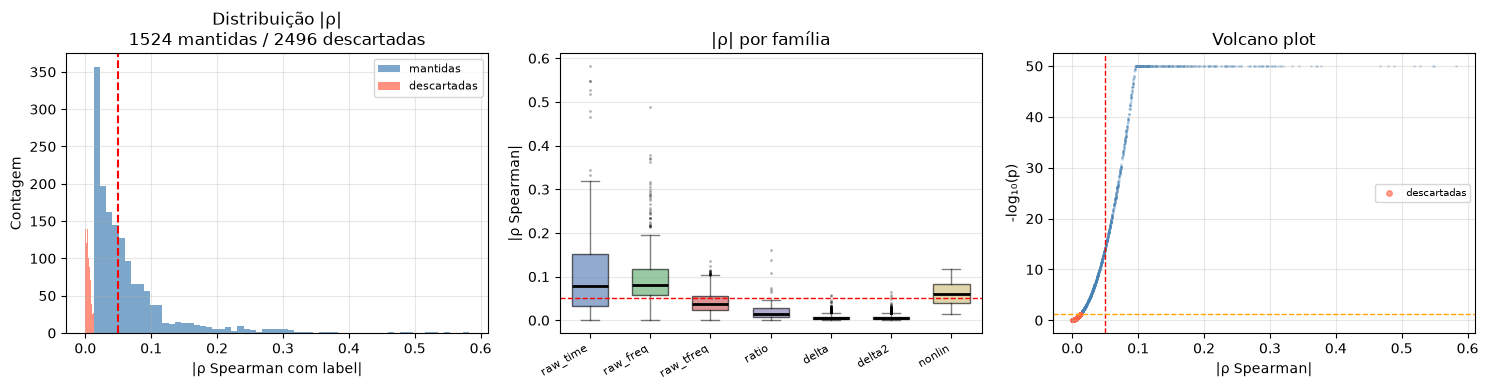

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (a) Histograma de |rho|
ax = axes[0]
ax.hist(np.abs(rho[keep_mask]),  bins=60, color='steelblue', alpha=0.7, label='mantidas')
ax.hist(np.abs(rho[~keep_mask]), bins=30, color='tomato',    alpha=0.7, label='descartadas')
ax.axvline(0.05, color='red', ls='--', lw=1.5)
ax.set_xlabel('|ρ Spearman com label|')
ax.set_ylabel('Contagem')
ax.set_title(f'Distribuição |ρ|\n{len(feat_kept)} mantidas / {n_dropped_sp} descartadas')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# (b) |rho| por família de feature
ax = axes[1]
families = {
    'raw_time'  : [i for i, c in enumerate(feat_all_cols) if '__time__'   in c and '__delta' not in c],
    'raw_freq'  : [i for i, c in enumerate(feat_all_cols) if '__freq__'   in c and '__delta' not in c],
    'raw_tfreq' : [i for i, c in enumerate(feat_all_cols) if '__tfreq__'  in c and '__delta' not in c],
    'ratio'     : [i for i, c in enumerate(feat_all_cols) if ('__ratio__' in c or '__asym__' in c) and '__delta' not in c],
    'delta'     : [i for i, c in enumerate(feat_all_cols) if c.endswith('__delta')],
    'delta2'    : [i for i, c in enumerate(feat_all_cols) if c.endswith('__delta2')],
    'nonlin'    : [i for i, c in enumerate(feat_all_cols) if '__nonlin__' in c and '__delta' not in c],
}
colors_fam = ['#4c72b0','#55a868','#c44e52','#8172b2','#937860','#da8bc3','#ccb974']
pos = 0
tick_pos, tick_lbl = [], []
for (fname, idxs), col in zip(families.items(), colors_fam):
    if not idxs:
        continue
    bp = ax.boxplot(np.abs(rho[idxs]), positions=[pos], widths=0.6, patch_artist=True,
                    medianprops=dict(color='black', lw=2),
                    whiskerprops=dict(alpha=0.5), capprops=dict(alpha=0.5),
                    flierprops=dict(marker='.', ms=2, alpha=0.3))
    bp['boxes'][0].set_facecolor(col); bp['boxes'][0].set_alpha(0.6)
    tick_pos.append(pos); tick_lbl.append(fname); pos += 1
ax.axhline(0.05, color='red', ls='--', lw=1)
ax.set_xticks(tick_pos); ax.set_xticklabels(tick_lbl, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('|ρ Spearman|'); ax.set_title('|ρ| por família'); ax.grid(True, alpha=0.3, axis='y')

# (c) Volcano: |rho| × -log10(p)
ax = axes[2]
xp = np.abs(rho); yp = np.clip(-np.log10(p_vals + 1e-300), 0, 50)
ax.scatter(xp[keep_mask],  yp[keep_mask],  s=1, alpha=0.2, c='steelblue')
ax.scatter(xp[~keep_mask], yp[~keep_mask], s=4, alpha=0.6, c='tomato', label='descartadas')
ax.axvline(0.05, color='red', ls='--', lw=1)
ax.axhline(-np.log10(0.05), color='orange', ls='--', lw=1)
ax.set_xlabel('|ρ Spearman|'); ax.set_ylabel('-log₁₀(p)')
ax.set_title('Volcano plot'); ax.legend(fontsize=7, markerscale=2); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
print('Passo 4b — Deduplicação por redundância (|r_Pearson| > 0.95 no mesmo canal)...')
t0 = time.time()

def ch_prefix(col):
    return col.split('__')[0]

channels_unique = sorted({ch_prefix(c) for c in feat_kept})
kept_final = []
n_drop_red = 0

for ch in channels_unique:
    ch_cols = [c for c in feat_kept if ch_prefix(c) == ch]
    if len(ch_cols) <= 1:
        kept_final.extend(ch_cols)
        continue

    # Ordenar por |rho| desc: preferir features mais discriminativas
    ch_cols_ord = sorted(ch_cols, key=lambda c: -abs(rho_dict[c]))

    # Pearson correlation matrix (≈ Spearman em dados ranqueados)
    X_ch = df_bl[ch_cols_ord].fillna(df_bl[ch_cols_ord].mean()).values.astype(np.float64)
    X_dm = X_ch - X_ch.mean(axis=0)
    std  = X_ch.std(axis=0) + 1e-15
    corr = (X_dm.T @ X_dm) / (N_WIN * np.outer(std, std))
    np.fill_diagonal(corr, 0.0)

    # Seleção gananciosa
    dropped  = set()
    selected = []
    for k, col in enumerate(ch_cols_ord):
        if col in dropped:
            continue
        selected.append(col)
        for l in range(k + 1, len(ch_cols_ord)):
            other = ch_cols_ord[l]
            if other not in dropped and abs(corr[k, l]) > 0.95:
                dropped.add(other)

    kept_final.extend(selected)
    n_drop_red += len(ch_cols) - len(selected)

print(f'  Após Spearman    : {len(feat_kept)}')
print(f'  Descartadas (red): {n_drop_red}')
print(f'  Features finais  : {len(kept_final)}  ({time.time()-t0:.1f}s)')

# ── Salvar ────────────────────────────────────────────────────────────────────
print()
print('Salvando features_engineered.parquet...')
out_cols = META_COLS + kept_final
df_out   = df_bl[out_cols].copy()
# Converter features para float32 para economizar disco
for c in kept_final:
    df_out[c] = df_out[c].astype(np.float32)
df_out.to_parquet(OUT_PATH, index=False)

size_mb = OUT_PATH.stat().st_size / 1e6
print(f'  ✅ {OUT_PATH.name}')
print(f'     {N_WIN:,} janelas × {len(kept_final)} features  ({size_mb:.1f} MB)')

Passo 4b — Deduplicação por redundância (|r_Pearson| > 0.95 no mesmo canal)...
  Após Spearman    : 1524
  Descartadas (red): 154
  Features finais  : 1370  (1.0s)

Salvando features_engineered.parquet...
  ✅ features_engineered.parquet
     24,564 janelas × 1370 features  (167.1 MB)


In [18]:
df_check   = pd.read_parquet(OUT_PATH)
feat_final = [c for c in df_check.columns if c not in META_COLS]

print('=' * 65)
print('FEATURE ENGINEERING — RESUMO FINAL (Entregável 7)')
print('=' * 65)
print()
print('Pipeline:')
print(f'  features_raw.parquet  → {N_WIN:,} × {N_FEAT}')
print(f'  + {n_ratio} razões espectrais  → {N_FEAT + n_ratio}')
print(f'  + Δ e Δ²             → {N_FEAT + n_ratio + 2*n_base}')
print(f'  - {n_dropped_sp} sem correlação  → {N_FEAT + n_ratio + 2*n_base - n_dropped_sp}')
print(f'  - {n_drop_red} redundantes     → {len(feat_final)}')
print()

fam_counts = {
    'raw_time'  : sum(1 for c in feat_final if '__time__'   in c and '__delta' not in c),
    'raw_freq'  : sum(1 for c in feat_final if '__freq__'   in c and '__delta' not in c),
    'raw_tfreq' : sum(1 for c in feat_final if '__tfreq__'  in c and '__delta' not in c),
    'raw_nonlin': sum(1 for c in feat_final if '__nonlin__' in c and '__delta' not in c),
    'ratio'     : sum(1 for c in feat_final if ('__ratio__' in c or '__asym__' in c) and '__delta' not in c),
    'delta'     : sum(1 for c in feat_final if c.endswith('__delta')),
    'delta2'    : sum(1 for c in feat_final if c.endswith('__delta2')),
}
print('Features finais por família:')
for fname, cnt in fam_counts.items():
    if cnt:
        print(f'  {fname:<15}: {cnt:>5}')
print(f'  {"TOTAL":<15}: {len(feat_final):>5}')
print()
nan_pct = df_check[feat_final].isna().mean().mean() * 100
print(f'NaN médio: {nan_pct:.1f}%')
print(f'Tamanho  : {OUT_PATH.stat().st_size/1e6:.1f} MB')
print()
print('Próximo passo: classificação_1.ipynb')
print('  → Validação cruzada LOSO (Leave-One-Subject-Out)')
print('  → Modelos: Random Forest, XGBoost, SVM')
print('=' * 65)

FEATURE ENGINEERING — RESUMO FINAL (Entregável 7)

Pipeline:
  features_raw.parquet  → 24,564 × 1251
  + 89 razões espectrais  → 1340
  + Δ e Δ²             → 4020
  - 2496 sem correlação  → 1524
  - 154 redundantes     → 1370

Features finais por família:
  raw_time       :   201
  raw_freq       :   286
  raw_tfreq      :   530
  raw_nonlin     :     6
  ratio          :    39
  delta          :   153
  delta2         :   130
  TOTAL          :  1370

NaN médio: 5.2%
Tamanho  : 167.1 MB

Próximo passo: classificação_1.ipynb
  → Validação cruzada LOSO (Leave-One-Subject-Out)
  → Modelos: Random Forest, XGBoost, SVM
